In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


In [2]:

#gdf_rinde = gpd.read_file("datos_cosecha_300puntos.csv")
#gdf_rinde.head()

#Problema resuelto, Geopandas no lee .csv. Se lo lee con Pandas y luego se arma la geometría con gpd    
df = pd.read_csv('C:\ARIEL\Software\GIT\Mine\Caso Cba\datos_cosecha_300puntos.csv')

gdf_rinde = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitud'], df['Latitud'])
)
# 3. Le asignamos el sistema de origen (Lat/Lon estándar)
gdf_rinde = gdf_rinde.set_crs(epsg=4326)

# 4. Ahora sí, podés reproyectar sin que explote nada:
gdf_rinde_metros = gdf_rinde.to_crs(gdf_rinde.estimate_utm_crs())

# 5. Reproyectamos
gdf_rp = gdf_rinde_metros.to_crs(epsg=32720)
gdf_rp.head()

# 6. Estimar superficie del perimetro
gdf_rp['superficie_m2'] = gdf_rp.geometry.buffer(10).area
gdf_rp.head()

<>:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\ariel\AppData\Local\Temp\ipykernel_11096\2635470606.py:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  df = pd.read_csv('C:\ARIEL\Software\GIT\Mine\Caso Cba\datos_cosecha_300puntos.csv')


,ID_Punto,Longitud,Latitud,Rinde_kgHa,Humedad_pct,geometry,superficie_m2
0,1,-62.8953,-31.2825,11674,14.9,POINT (509965.712 6539084.556),313.654849
1,2,-62.8903,-31.2865,10153,15.7,POINT (510441.189 6538640.773),313.654849
2,3,-62.8935,-31.2836,11252,15.1,POINT (510136.924 6538962.479),313.654849
3,4,-62.8983,-31.2789,12882,14.3,POINT (509680.529 6539483.811),313.654849
4,5,-62.8919,-31.2855,10839,15.3,POINT (510289.01 6538751.754),313.654849


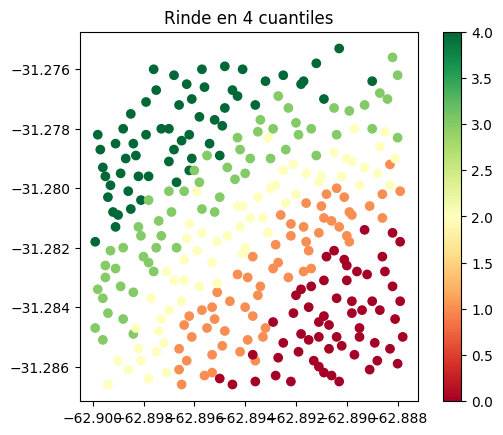

In [3]:
gdf_rinde['cuantiles'] = pd.qcut(gdf_rinde['Rinde_kgHa'], 5, labels=False)

gdf_rinde.plot(column='cuantiles', cmap='RdYlGn', legend=True)
plt.title('Rinde en 4 cuantiles')
plt.show()


In [4]:
#Añadir la capa de rendimientos en un mapa interactivo con Plotly
fig = go.Figure()
fig.add_trace(go.Scattermapbox(
    lat=gdf_rinde['Latitud'],
    lon=gdf_rinde['Longitud'],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=10,
        color=gdf_rinde['Rinde_kgHa'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title='Rinde (kg/ha)')
    ),
    text=gdf_rinde['Rinde_kgHa'],
    hoverinfo='text'
))
fig.update_layout(
    mapbox_style="white-bg", # Ponemos el fondo en blanco
    mapbox_layers=[
        {
            "below": 'traces', # Para que el satélite quede por debajo de tus puntos de rinde
            "sourcetype": "raster",
            "sourceattribution": "Google",
            "source": [
                "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}" # URL del satélite de Google
            ]
        }
    ],
    mapbox_center={"lat": gdf_rinde['Latitud'].mean(), "lon": gdf_rinde['Longitud'].mean()},
    mapbox_zoom=13, # Te subí un poco el zoom (14 o 15 suele ser mejor para ver lotes)
    title="Rinde en el campo"
)
fig.show()

#lo hago html
fig.write_html("mapa_rinde.html")
print("Mapa guardado como mapa_rinde.html")


C:\Users\ariel\AppData\Local\Temp\ipykernel_11096\3337570891.py:3: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


Mapa guardado como mapa_rinde.html


In [5]:
# Vamos a crear un archivo .shp la geometria del lote
geometry = gpd.GeoSeries.from_wkt([gdf_rinde.geometry.unary_union.convex_hull.wkt])
gdf_lote = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")
gdf_lote.to_file("lote.shp")
print("Archivo lote.shp creado para QGIS")

C:\Users\ariel\AppData\Local\Temp\ipykernel_11096\3924353036.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry = gpd.GeoSeries.from_wkt([gdf_rinde.geometry.unary_union.convex_hull.wkt])


Archivo lote.shp creado para QGIS


In [6]:
# ============================================================
# CELDA 0 — CONFIGURACIÓN
# Editá estas variables antes de correr el notebook.
# Para mayor seguridad podés usar variables de entorno:
#   import os; GEE_PROJECT = os.environ.get('GEE_PROJECT', 'tu-proyecto')
# ============================================================

GEE_PROJECT   = 'my-project-12126-484118'   # <-- Reemplazá con tu project ID de GEE
CENTRO_LAT   = 33.584              # Latitud del centro del mapa inicial
CENTRO_LON   = -101.845            # Longitud del centro del mapa inicial
ZOOM_INICIAL  = 13
ANIOS_ATRAS   = 3
MAX_NUBES     = 30                  # Umbral de cobertura nubosa (%)
K_EXTINCTION  = 0.5                 # Coef. extinción Beer-Lambert (0.4–0.6 para cultivos)
SAVI_L        = 0.5                 # Factor de corrección de suelo para SAVI (0=suelo desnudo, 1=canopeo cerrado)

print("✅ Configuración cargada.")
print(f"   Proyecto GEE : {GEE_PROJECT}")
print(f"   Centro mapa  : ({CENTRO_LAT}, {CENTRO_LON})")
print(f"   Ventana      : {ANIOS_ATRAS} años | Nubes ≤ {MAX_NUBES}% | k={K_EXTINCTION} | L={SAVI_L}")

✅ Configuración cargada.
   Proyecto GEE : my-project-12126-484118
   Centro mapa  : (33.584, -101.845)
   Ventana      : 3 años | Nubes ≤ 30% | k=0.5 | L=0.5


In [7]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import requests
import io
import urllib
import warnings
import ipywidgets as widgets
import plotly.graph_objects as go
import plotly.express as px
from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union
from IPython.display import display, HTML, FileLink
from contextlib import redirect_stdout
import json
import tempfile
import os

In [ ]:
import ee
import geemap
import os
import io
import json
import geopandas as gpd
import tempfile
import ipywidgets as widgets

from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union
from IPython.display import FileLink, display

# --- Autenticación GEE ---
try:
    ee.Initialize(project='myproject-12126-484118')
    print("✅ Earth Engine inicializado.")
except Exception:
    print("🔑 Autenticando Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project='my-project-12126-484118')
    print("✅ Earth Engine inicializado.")

# ── Variable compartida entre ambos flujos ──────────────────
lote_geom      = None   # ee.Geometry — usada por celdas siguientes
lote_geom_shp  = None   # shapely geometry

# ============================================================
# MAPA INTERACTIVO
# ============================================================
Draw_Map = geemap.Map(center=[CENTRO_LAT, CENTRO_LON], zoom=ZOOM_INICIAL)
Draw_Map.add_basemap('SATELLITE')

# ── Botón: Confirmar polígono dibujado ──────────────────────
btn_confirmar = widgets.Button(
    description='✅ Confirmar polígono dibujado',
    button_style='success',
    layout=widgets.Layout(width='260px', margin='4px')
)
out_dibujo = widgets.Output()

def confirmar_poligono(b):
    global lote_geom, lote_geom_shp
    with out_dibujo:
        out_dibujo.clear_output()
        roi = Draw_Map.user_roi
        if roi is None:
            print("⚠️ No se detectó ningún polígono. Dibujá uno primero.")
            return

        roi_info  = roi.getInfo()
        lote_geom = ee.Geometry(roi_info.get('geometry', roi_info))
        coords    = lote_geom.coordinates().getInfo()[0]
        lote_geom_shp = Polygon(coords)

        print(f"✅ Polígono confirmado — {len(coords)-1} vértices")
        print(f"   Área aprox.: {lote_geom_shp.area * 111320**2 / 10000:.2f} ha")

        # ── Exportar como GeoJSON descargable ──
        geojson_str = json.dumps({
            "type": "FeatureCollection",
            "features": [{
                "type": "Feature",
                "geometry": mapping(lote_geom_shp),
                "properties": {"nombre": "lote"}
            }]
        }, indent=2)

        geojson_path = os.path.join(tempfile.gettempdir(), "lote.geojson")
        with open(geojson_path, "w") as f:
            f.write(geojson_str)

        # Copiar a directorio de trabajo para que el link funcione
        local_path = "lote_exportado.geojson"
        with open(local_path, "w") as f:
            f.write(geojson_str)

        print(f"\n📥 Descargá el polígono:")
        display(FileLink(local_path, result_html_prefix="👉 "))

btn_confirmar.on_click(confirmar_poligono)

# ============================================================
# CARGA DE SHAPEFILE LOCAL
# ============================================================

uploader = widgets.FileUpload(
    description='📂 Subir Lote (.shp / .geojson)',
    accept='.shp,.zip,.geojson',   # <-- Agregamos .geojson
    multiple=True,
    layout=widgets.Layout(width='260px', margin='4px')
)
btn_cargar = widgets.Button(
    description='📌 Cargar SHP al mapa',
    button_style='info',
    layout=widgets.Layout(width='260px', margin='4px')
)
out_shp = widgets.Output()

def cargar_shp(b):
    global lote_geom, lote_geom_shp
    with out_shp:
        out_shp.clear_output()
        archivos = uploader.value

        if not archivos:
            print("⚠️ No se subió ningún archivo.")
            return

        tmp_dir = tempfile.mkdtemp()
        
        # 1. Guardar componentes (ADENTRO DEL FOR)
        for archivo in uploader.value:
            nombre = archivo['name']
            contenido = archivo['content']
            with open(os.path.join(tmp_dir, nombre), 'wb') as f:
                f.write(contenido)

        # 2. Definir rutas y leer (ADENTRO DEL TRY)
        try:
            geojson_files = [f for f in os.listdir(tmp_dir) if f.endswith('.geojson')]
            shp_files = [f for f in os.listdir(tmp_dir) if f.endswith('.shp')]
            zip_files = [f for f in os.listdir(tmp_dir) if f.endswith('.zip')]

            if zip_files:
                import zipfile
                zip_path = os.path.join(tmp_dir, zip_files[0])
                with zipfile.ZipFile(zip_path, 'r') as z:
                    z.extractall(tmp_dir)
                shp_files = [f for f in os.listdir(tmp_dir) if f.endswith('.shp')]

            if geojson_files:
                archivo_path = os.path.join(tmp_dir, geojson_files[0])
            elif shp_files:
                archivo_path = os.path.join(tmp_dir, shp_files[0])
            else:
                print("❌ No se encontró .shp ni .geojson.")
                return

            gdf = gpd.read_file(archivo_path).to_crs(epsg=4326)

            # 3. Procesar geometría
            lote_geom_shp = unary_union(gdf.geometry)
            geojson_geom  = mapping(lote_geom_shp)
            lote_geom     = ee.Geometry(geojson_geom)

            print(f"✅ Archivo cargado: {len(gdf)} feature(s) — reproyectado a EPSG:4326")
            print(f"   Área aprox.: {lote_geom_shp.area * 111320**2 / 10000:.2f} ha")

            # 4. Mostrar en mapa
            with redirect_stdout(io.StringIO()):
                Draw_Map.add_gdf(
                    gdf,
                    layer_name="Lote Vectorial",
                    style={'color': '#f1c40f', 'weight': 2, 'fillOpacity': 0.2}
                )
            print("🗺️  Lote agregado al mapa.")

        except Exception as e:
            print(f"❌ Error al leer el archivo: {e}")

btn_cargar.on_click(cargar_shp)

# ============================================================
# LAYOUT FINAL
# ============================================================
titulo = widgets.HTML("<h3 style='margin:8px 0'>📍 Definición del lote</h3>")

panel_dibujo = widgets.VBox([
    widgets.HTML("<b>Opción A — Dibujar en el mapa</b><br><small>Usá el polígono del panel izquierdo</small>"),
    btn_confirmar,
    out_dibujo
], layout=widgets.Layout(padding='10px', border='1px solid #ccc', margin='4px', width='300px'))

panel_shp = widgets.VBox([
    widgets.HTML("<b>Opción B — Subir Shapefile</b><br><small>Subí el .zip (shp+dbf+shx+prj) o los archivos sueltos</small>"),
    uploader,
    btn_cargar,
    out_shp
], layout=widgets.Layout(padding='10px', border='1px solid #ccc', margin='4px', width='500px'))

display(titulo)
display(Draw_Map)
display(widgets.HBox([panel_dibujo, panel_shp]))

print("\n💡 Tip: podés dibujar Y también cargar un SHP — el último confirmado queda activo como 'lote_geom'.")

🔑 Autenticando Earth Engine...
✅ Earth Engine inicializado.


HTML(value="<h3 style='margin:8px 0'>📍 Definición del lote</h3>")

Map(center=[33.584, -101.845], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…


💡 Tip: podés dibujar Y también cargar un SHP — el último confirmado queda activo como 'lote_geom'.


In [25]:
# ============================================================
# CELDA 2 — ANÁLISIS COMPLETO
# ============================================================
import os
import sys
from shapely.geometry import shape
import pandas as pd

# Ajustar ruta para importar módulos locales (asumiendo estructura de carpetas)

climate_dir = os.path.abspath(os.path.join(os.getcwd(), 'Climate'))
if not os.path.isdir(climate_dir):
    climate_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'Climate'))
if not os.path.isdir(climate_dir):
    climate_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'Climate'))
if not os.path.isdir(climate_dir):
    raise FileNotFoundError(f"No se encontró la carpeta Climate en: {os.getcwd()} o rutas relativas.")
if climate_dir not in sys.path:
    sys.path.insert(0, climate_dir)

#from gee_utils      import obtener_fecha_maxima, calcular_periodos, descargar_serie
from gee_utils      import obtener_fecha_maxima, calcular_periodos, descargar_serie
from agro_metrics   import calcular_eto_pm, calcular_hr, agregar_mensual, procesar_diario
from plots          import mostrar_graficos
from config         import ERA5_COLLECTION, T_BASE

# 1. Verificar dibujo
if lote_geom is None:
    raise ValueError("⚠️ No se definió ningún lote. Volvé a la Celda 1, dibujá o subí un archivo y confirmá.")

print("📐 Configurando geometría del lote...")
punto_clima = lote_geom  # área completa del lote, no centroide

# 2. Geometría del lote (área completa, no centroide)
centroid  = lote_geom.centroid(maxError=1).coordinates().getInfo()
latitud   = centroid[1]   # necesaria para ETo PM

# 3. Fechas automáticas
era5_base = ee.ImageCollection(ERA5_COLLECTION).filterBounds(lote_geom)
fecha_max = obtener_fecha_maxima(era5_base)
hist_start, hist_end, daily_start, daily_end = calcular_periodos(fecha_max)

print(f'📅 Histórico  : {hist_start} → {hist_end}')
print(f'📅 Mes actual : {daily_start} → {daily_end}')

# 4. Descarga ERA5 (area mean sobre el lote, no centroide)
df = descargar_serie(lote_geom, hist_start, hist_end)

# 5. Métricas agronómicas
df['eto'] = calcular_eto_pm(df, latitud)
df['hr']  = calcular_hr(df)

# 6. Agregación mensual
df_mensual = agregar_mensual(df)

# 7. Detalle diario del mes actual
df_diario = procesar_diario(df, daily_start, daily_end)
df_diario.attrs['t_base'] = T_BASE   # para label del gráfico

# 8. Métricas resumen (imprimir antes de los gráficos)
mes_actual = df_mensual.iloc[-1]
print(f'\n📊 Resumen del último mes disponible ({mes_actual["mes_año"].strftime("%b %Y")})')
print(f'   Lluvia      : {mes_actual["precip"]:.1f} mm')
print(f'   ETo PM      : {mes_actual["eto"]:.1f} mm')
print(f'   Balance     : {mes_actual["balance_hidro"]:+.1f} mm')
print(f'   T. media    : {mes_actual["t_med"]:.1f} °C')
print(f'   HR media    : {mes_actual["hr"]:.0f} %')

# 9. Gráficos
print('\n📈 Generando gráficos interactivos...')
mostrar_graficos(df_mensual, df_diario, daily_start, daily_end)

📐 Configurando geometría del lote...
📅 Histórico  : 2023-04-01 → 2026-04-27
📅 Mes actual : 2026-04-01 → 2026-04-27
📡 Descargando serie temporal ERA5-Land (20-40 seg aprox.)...
✅ 1123 días descargados (2023-04-01 → 2026-04-27)

📊 Resumen del último mes disponible (Apr 2026)
   Lluvia      : 114.4 mm
   ETo PM      : 46.2 mm
   Balance     : +68.2 mm
   T. media    : 19.0 °C
   HR media    : 77 %

📈 Generando gráficos interactivos...
